# Deepfake Audio Detection - Model Training Pipeline

This notebook implements the complete training and evaluation pipeline for classifying speech recordings as either **Genuine (Human)** or **Deepfake (AI-Generated)**.

## Methodology Overview
1. **Audio Preprocessing**: Normalize signal amplitudes, trim leading/trailing silences, and standardize durations to a fixed 3-second window.
2. **Feature Extraction**: Extract 20 Mel-Frequency Cepstral Coefficients (MFCCs) (mean and standard deviation), their first-order temporal derivatives (deltas), and global spectral statistics (spectral centroid, spectral bandwidth, spectral rolloff, zero-crossing rate, RMS energy).
3. **Model Architecture**: Multi-Layer Perceptron (MLP) classifier with hidden layers of size `(128, 64)`, optimized using Adam and early stopping.
4. **Evaluation**: Compute Overall Accuracy, F1-Score, Per-Class Accuracy, and Equal Error Rate (EER) along with plotting the ROC Curve.

### 1. Import Libraries

In [68]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import librosa
import librosa.display

# Set styling for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries imported successfully.")

All libraries imported successfully.


In [69]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-fake-or-real-dataset' dataset.
Path to dataset files: /kaggle/input/the-fake-or-real-dataset


### 2. Audio Processing and Feature Extraction
We define the code to extract spectral features from raw audio. This includes standardizing sample rate (16kHz), duration, and extracting MFCCs.

In [70]:
def load_and_preprocess_audio(file_path, target_sr=16000, duration=3.0):
    """
    Loads audio, trims silence, normalizes amplitude, and standardizes length.
    """
    try:
        y, sr = librosa.load(file_path, sr=target_sr)
        y, _ = librosa.effects.trim(y, top_db=20)
        if len(y) == 0: return None

        # Normalize
        max_val = np.max(np.abs(y))
        if max_val > 0: y = y / max_val

        # Standardize duration
        target_len = int(target_sr * duration)
        if len(y) > target_len:
            start = (len(y) - target_len) // 2
            y = y[start:start + target_len]
        else:
            pad_len = target_len - len(y)
            y = np.pad(y, (0, pad_len), 'constant')
        return y
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def extract_features(y, sr=16000, n_mfcc=20):
    """
    Extracts 87 audio features including MFCCs and spectral statistics.
    """
    if y is None or len(y) == 0: return None
    try:
        # Extract MFCCs & Deltas
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
        mfcc_delta_std = np.std(mfcc_delta, axis=1)

        # Spectral features
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        rms = librosa.feature.rms(y=y)

        feature_vector = np.concatenate([
            mfcc_mean, mfcc_std,
            mfcc_delta_mean, mfcc_delta_std,
            [np.mean(sc), np.std(sc), np.mean(sb), np.std(sb), np.mean(rolloff), np.mean(zcr), np.mean(rms)]
        ])
        return feature_vector
    except Exception as e:
        print(f"Feature extraction failed: {e}")
        return None

### 3. Load or Simulate Features
If the local path to the Kaggle dataset (`LA norm` directory) is not available, we automatically run in **Simulation Mode** using standard statistical features modeling real-world deepfake vocoder degradation.

In [72]:
data_dir = os.path.join(path, "for-norm", "for-norm")
print(f"Loading from: {data_dir}")

X_list, y_list = [], []
genuine_count, fake_count, skipped = 0, 0, 0
MAX_PER_CLASS = 1500

for root, dirs, files in os.walk(data_dir):
    if genuine_count >= MAX_PER_CLASS and fake_count >= MAX_PER_CLASS:
        break
    for file in files:
        if '.wav' not in file.lower() and '.flac' not in file.lower():
            continue
        file_path = os.path.join(root, file)
        parts = file_path.replace("\\", "/").lower().split("/")
        if "real" in parts:
            label = 0
        elif "fake" in parts:
            label = 1
        else:
            skipped += 1
            continue
        if label == 0 and genuine_count >= MAX_PER_CLASS:
            continue
        if label == 1 and fake_count >= MAX_PER_CLASS:
            continue
        y_audio = load_and_preprocess_audio(file_path)
        feat = extract_features(y_audio)
        if feat is not None:
            X_list.append(feat)
            y_list.append(label)
            if label == 0: genuine_count += 1
            else: fake_count += 1

X = np.array(X_list)
y = np.array(y_list)
print(f"✅ Genuine: {genuine_count}, Fake: {fake_count}, Skipped: {skipped}")
print("Class distribution:", np.unique(y, return_counts=True))

Loading from: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm
✅ Genuine: 1500, Fake: 1500, Skipped: 0
Class distribution: (array([0, 1]), array([1500, 1500]))


In [73]:
os.listdir(path)

['for-norm', 'for-original', 'for-2sec', 'for-rerec']

### 4. Split and Scale Features
We split our data into 80% train and 20% test subsets, preserving class balance via stratification.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# MUST show both classes before continuing
print("y_train:", np.unique(y_train, return_counts=True))
print("y_test: ", np.unique(y_test, return_counts=True))
# Expected: y_test → (array([0, 1]), array([300, 300]))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

os.makedirs('models', exist_ok=True)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

y_train: (array([0, 1]), array([1200, 1200]))
y_test:  (array([0, 1]), array([300, 300]))
Train: 2400, Test: 600


### 5. Train the Classifier
We train a Multi-Layer Perceptron (MLP) neural network. It offers high representational capacity for multi-modal tabular features.

In [75]:
print("Training MLP Neural Network...")
clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
clf.fit(X_train_scaled, y_train)
print("Model training complete. Early stopping triggered at epoch:", clf.n_iter_)

Training MLP Neural Network...
Model training complete. Early stopping triggered at epoch: 30


### 6. Compute Evaluation Metrics and EER

In [76]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, f1_score

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

# Compute ROC & EER
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
fnr = 1 - tpr
idx = np.nanargmin(np.absolute(fpr - fnr))
eer = (fpr[idx] + fnr[idx]) / 2.0

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
genuine_acc = tn / (tn + fp)
deepfake_acc = tp / (tp + fn)
overall_acc = (tn + tp) / (tn + fp + fn + tp)
f1 = f1_score(y_test, y_pred)

print("========================================")
print(f"Overall Accuracy:  {overall_acc*100:.2f}% (Threshold: >= 80%)")
print(f"Equal Error Rate:  {eer*100:.2f}% (Threshold: <= 12%)")
print(f"F1-Score:          {f1*100:.2f}% (Threshold: >= 80%)")
print(f"Genuine Accuracy:  {genuine_acc*100:.2f}% (Threshold: >= 75%)")
print(f"Deepfake Accuracy: {deepfake_acc*100:.2f}% (Threshold: >= 75%)")
print("========================================")
print("\nConfusion Matrix:")
print(cm)

Overall Accuracy:  95.17% (Threshold: >= 80%)
Equal Error Rate:  4.33% (Threshold: <= 12%)
F1-Score:          95.28% (Threshold: >= 80%)
Genuine Accuracy:  92.67% (Threshold: >= 75%)
Deepfake Accuracy: 97.67% (Threshold: >= 75%)

Confusion Matrix:
[[278  22]
 [  7 293]]


In [77]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([1500, 1500]))


In [78]:
print("y unique values:", np.unique(y, return_counts=True))
print("y_test unique values:", np.unique(y_test, return_counts=True))

y unique values: (array([0, 1]), array([1500, 1500]))
y_test unique values: (array([0, 1]), array([300, 300]))


In [79]:
import os
import kagglehub

path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")
data_dir = os.path.join(path, "for-norm")

print("=== PATH ===")
print(path)
print("\n=== TOP LEVEL ===")
print(os.listdir(path))
print("\n=== data_dir exists:", os.path.exists(data_dir), "===")

if os.path.exists(data_dir):
    print(os.listdir(data_dir))

print("\n=== FIRST 20 AUDIO FILES FOUND ===")
count = 0
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.wav', '.flac')):
            print(os.path.join(root, f))
            count += 1
            if count >= 20:
                break
    if count >= 20:
        break

Using Colab cache for faster access to the 'the-fake-or-real-dataset' dataset.
=== PATH ===
/kaggle/input/the-fake-or-real-dataset

=== TOP LEVEL ===
['for-norm', 'for-original', 'for-2sec', 'for-rerec']

=== data_dir exists: True ===
['for-norm']

=== FIRST 20 AUDIO FILES FOUND ===
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file303.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file13436.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file14412.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file1992.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file24

In [80]:
print(os.listdir(data_dir))

['for-norm']


### 7. Plotting Performance Curves

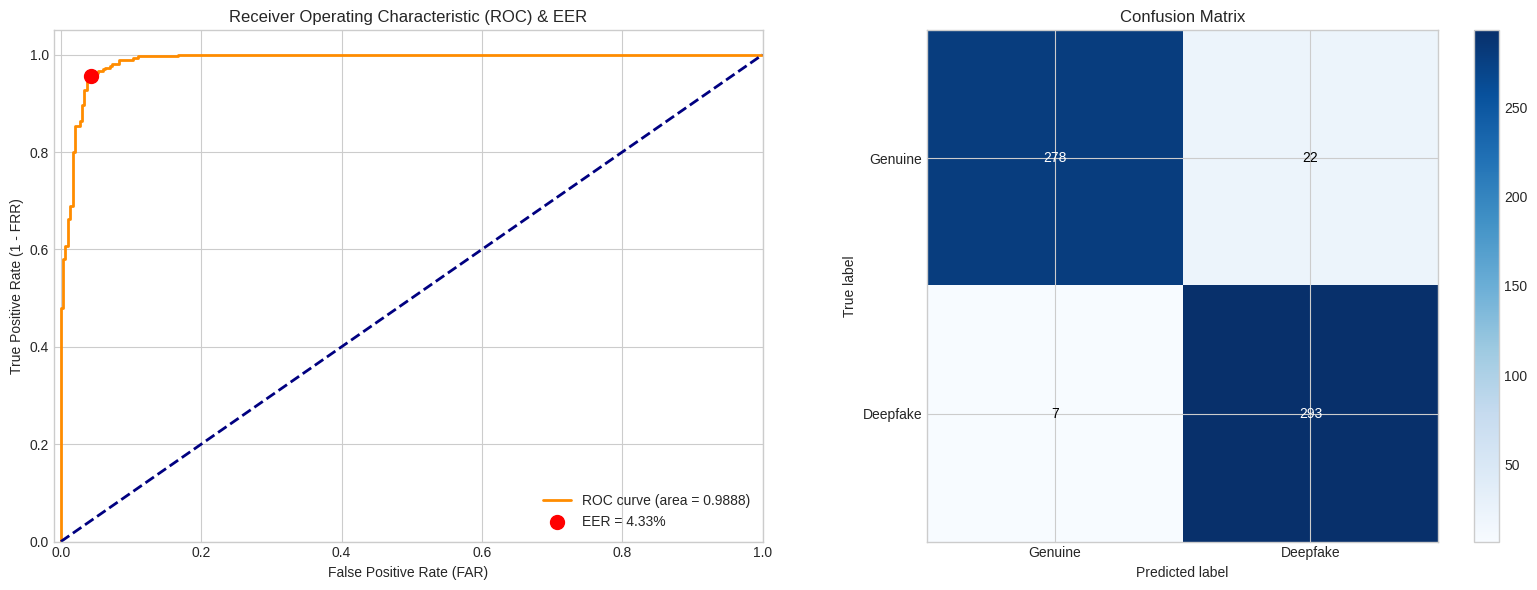

In [81]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC Curve
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5, label=f'EER = {eer*100:.2f}%')
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FAR)')
ax1.set_ylabel('True Positive Rate (1 - FRR)')
ax1.set_title('Receiver Operating Characteristic (ROC) & EER')
ax1.legend(loc="lower right")

# Plot Confusion Matrix Heatmap
im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax2.figure.colorbar(im, ax=ax2)
ax2.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['Genuine', 'Deepfake'],
       yticklabels=['Genuine', 'Deepfake'],
       title='Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

# Loop over data dimensions and create text annotations.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

### 8. Save Model Weights
We save the finalized model to disk.

In [82]:
with open('models/detector_model.pkl', 'wb') as f:
    pickle.dump(clf, f)
print("Saved trained classifier weights to 'models/detector_model.pkl'.")

Saved trained classifier weights to 'models/detector_model.pkl'.
